# Characters Search Engine

To disambiguate the characters of Game of Thrones books, we need to have an authoritative source, curated and verified containing the final list of all characters. 

This list exist in the [wiki of ice and fire](https://awoiaf.westeros.org). So we want to build a search engine based on this wiki to send a character partial name and get the most corresponding list of potential characters, ranked. 

Many methods for ranking exists, from the search engine specific network analysis to building a custom function. Like all modern search engine, we will create our own ranking algorithm that will use many features as based data. 

To create our search engine we need to follow the following steps:
1. Download the HTML page for each character
2. Scrape the HTML page and extract relevant informations using beautiful soup
3. create the network of characters to create the page rank feature 
4. create the Bag of Words (BOW) that will be the basis for the search engine
5. optimize the search engine using our list of features 

## 1. Download the HTML page for each character

To download the characters we need to do it in two steps:
1. get a list of pages we shall scrape
2. scrape all the pages


### *****for this can see the1 scrape pages.jpynb,I have get all the html sucessfully

Let's start by importing the required libraries to perform this task

In [1]:
# you work

To not be stopped by the awoif website, we hide ourselves very simply by changing the default python requests User-Agent

## 2. Scrape the HTML page and extract relevant informations using beautiful soup

Now that we have a directory containing all the html pages, we can read all files and convert it in a soup. 

From the soup we can extract all required informations

List of information to get from every page: 
1. title of the page
2. infobox name
3. aliases
4. page rank -> need to get Links to other pages
5. length of the text
6. books
7. mentionned or appear in each book
8. __the main text CLEANED__

### 2.1~2,4 please look and run in the extract my awoif_heavy2.ipynb


### 2.5 LOAD THE PICKLE

In [12]:
import pickle
import warnings

# 1. 加载数据
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    with open("awoif_heavy2.pkl", "rb") as f:
        df = pickle.load(f)

# ---------------------------------------------------------
# 2. 核心查看命令 (这三行最常用)
# ---------------------------------------------------------

print(f"数据形状 (行数, 列数): {df.shape}")
print("\n" + "-" * 50 + "\n")

print("列名 (提取的特征字段):")
print(df.columns.tolist())
print("\n" + "-" * 50 + "\n")

print("前 5 行数据预览:")
display(df.head()) # 如果是纯 Python 脚本，用 print(df.head())

数据形状 (行数, 列数): (3594, 21)

--------------------------------------------------

列名 (提取的特征字段):
['page', 'Identity_title', 'Identity_og_title', 'Identity_meta_description', 'Identity_article_id', 'Infobox_allegiances', 'Infobox_culture', 'Infobox_born', 'Infobox_died', 'Infobox_spouses', 'Infobox_infobox_fields_count', 'Names_aliases', 'Names_all_name_variants', 'Text_text_length', 'Text_word_count', 'Text_paragraph_count', 'Structure_sections', 'Structure_section_count', 'Links_links_out_count', 'Categories_categories', 'Categories_category_count']

--------------------------------------------------

前 5 行数据预览:


,page,Identity_title,Identity_og_title,Identity_meta_description,Identity_article_id,Infobox_allegiances,Infobox_culture,Infobox_born,Infobox_died,Infobox_spouses,...,Names_aliases,Names_all_name_variants,Text_text_length,Text_word_count,Text_paragraph_count,Structure_sections,Structure_section_count,Links_links_out_count,Categories_categories,Categories_category_count
0,Abelar_Hightower,Abelar Hightower,Abelar Hightower,Abelar Hightower was a knight from House Hight...,Abelar_Hightower,House Hightower,Reach,"the Hightower[1], Oldtown",NaN,None,...,NaN,NaN,983,165,4,"[Appearance and Character, History, References]",3,10,"[House Hightower, 2nd century AC births, 3rd c...",6
1,Abelon,Abelon,Abelon,Abelon was an archmaester of the Citadel and t...,Abelon,The Citadel,Westerosi,NaN,NaN,None,...,NaN,NaN,104,18,1,[References],1,10,"[Archmaesters, Characters from Westeros, Scribes]",3
2,Addam_Frey,Addam Frey,Addam Frey,Addam Frey was a knight from House Frey during...,Addam_Frey,House Frey,Rivermen,the Twins[1],NaN,None,...,NaN,NaN,618,107,5,"[History, Family, References]",3,10,"[House Frey, 2nd century AC births, 3rd centur...",6
3,Addam_Hightower,Addam Hightower,Addam Hightower,Addam Hightower was Lord of the Hightower and ...,Addam_Hightower,NaN,Reach,In or before 22 BC[2],10–23 AC[2],None,...,NaN,NaN,1353,242,5,"[History, Family, References]",3,11,"[House Hightower, 1st century BC births, 1st c...",8
4,Addam_Marbrand,Addam Marbrand,Addam Marbrand,"Addam Marbrand is a knight of House Marbrand, ...",Addam_Marbrand,NaN,Westermen,Ashemark[3],NaN,None,...,NaN,NaN,8683,1462,27,"[Appearance and Character, History, Recent Eve...",12,16,"[House Marbrand, 3rd century AC births, Charac...",14


In [13]:
import pandas as pd

df = pd.read_pickle('awoif_heavy.pkl')
#so if  have finished the "extract my awoif_heavy2.ipynb",you can use it
#df = pd.read_pickle('awoif_heavy.pkl2')


In [9]:
!pip install scipy

## 3 create a network to have network ranking features

The network has to be created using pages and links in the pages. 

### 3.1 create the network

In [2]:
import networkx as nx

In [3]:
G = nx.DiGraph()

for each page for each character we add all the links to other characters

In [4]:
def add_edges(x):
    u = x['page']
    vs = x['links']
    for v in vs:
        G.add_edge(u, v)

df[['page', 'links']].apply(lambda x: add_edges(x), axis=1)

0       None
1       None
2       None
3       None
4       None
        ... 
3664    None
3665    None
3666    None
3667    None
3668    None
Length: 3669, dtype: object

In [5]:
len(G.edges)

53079

In [6]:
print('–– Network Characteristics –– ')
print(f'\tNodes: {G.number_of_nodes()}')
print(f'\tEdges: {G.number_of_edges()}')

–– Network Characteristics –– 
	Nodes: 3468
	Edges: 53079


In [7]:
nx.write_gexf(G, 'awoif.gexf')

### 3.2 Calculate PageRank, Closeness Centrality and Betweeness Centrality

To calculate pageRank and centralities, refer to [networkx documentation](https://networkx.org/documentation/latest/ )

start with the pagerank and store it in a variable called __pr__

In [8]:
pr = nx.pagerank(G)

continue with the betweeness centrality and store it in a variable called __bc__

In [9]:
bc = nx.betweenness_centrality(G)

finish with the closeness centrality and store it in a variable called __cc__

In [10]:
cc = nx.closeness_centrality(G)

### 3.3 add each score as a new columns for all the pages in the dataframe

the columns shall be named respectively __pagerank__, __betweeness__, __closeness__

the pr, bc and cc are all dictionaries keyed with page name. 

The page name is in the column page of the dataframe sor make good use of:
 - apply function for dataframes
 - get function for dictionaries
 - lambda function from python 

In [11]:
df['pagerank'] = df.page.apply(lambda x: pr.get(x,0))

In [12]:
df['betweeness'] = df.page.apply(lambda x: bc.get(x,0))

In [13]:
df['closeness'] = df.page.apply(lambda x: cc.get(x,0))

### 3.4 check the influence of each network indicator

To measure the influence of each indicator, or the indicator bringing more information, we can start by checking if these indicators are correlated

Find the correlation between these 3 columns, what do you observe? 

_Hint: pandas as a correlation function_

In [14]:

df[['pagerank', 'betweeness', 'closeness']].corr()


,pagerank,betweeness,closeness
pagerank,1.000000,0.879694,0.436078
betweeness,0.879694,1.000000,0.258599
closeness,0.436078,0.258599,1.000000


Our space has 3 dimensions right now. We can use Principal component Analysis PCA to evaluate the information each variable bring.

Apply PCA method from sklearn to our 3 columns. see pdf join and [sklearn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

What can you conclude? Do we need the 3 variables? Which one explain the variance the most?

In [57]:
!pip install scikit-learn
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(df[['pagerank', 'betweeness', 'closeness']].to_numpy())

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

Print the explained variance ratio

In [58]:
pca.explained_variance_ratio_

array([9.99605519e-01, 3.91757432e-04])

print the components

In [59]:
pca.components_

array([[ 0.00172098,  0.00523463,  0.99998482],
       [ 0.15935139,  0.98720693, -0.00544199]])

To finish, let's plot the histogram of the network scores 

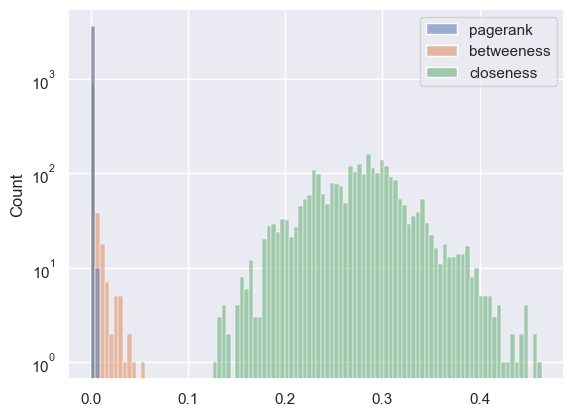

In [60]:
import seaborn as sns

sns.set()
ax = sns.histplot(df[['pagerank', 'betweeness', 'closeness']], bins=100)
ax.set_yscale('log')

## 3.5 create a custom distance 

Let's compare the ranking performance of our network indicator together

First create a combination of the three score, using an euclidean and a minkowski distance.

Why is it is done from 0,0,0 to something ? 

Why is axis = 1 ? 

In [61]:
from scipy.spatial import distance
df['euclidean'] = df[['pagerank', 'betweeness', 'closeness']].apply(lambda x : distance.euclidean([0,0,0],x.to_numpy()), axis=1)
df['minkowski'] = df[['pagerank', 'betweeness', 'closeness']].apply(lambda x : distance.minkowski([0,0,0],x.to_numpy()), axis=1) 



now we create a custom function that takes a list of pages, and return the top 10 according to the chosen ranking algorithm

In [62]:
#normalize features 数值归一化Z-score mean midrange数据归一化
def rank_these_pages(pages_list, method='euclidean'):
    results = df.loc[pages_list,:].sort_values(by=[method],ascending=False)[:10]
    return list(results.page)

at last we create a dataframe to easily see the difference between the ranking methods. 

What can you conclude? 

In [63]:
ranking_data = {'pagerank':rank_these_pages(df.index, method='pagerank'),
             'betweeness':rank_these_pages(df.index, method='betweeness'),
             'closeness':rank_these_pages(df.index, method='closeness'),
             'euclidean':rank_these_pages(df.index, method='euclidean'),
             'minkowski':rank_these_pages(df.index, method='minkowski')}
df_ranking = pd.DataFrame.from_dict(ranking_data)
df_ranking

,pagerank,betweeness,closeness,euclidean,minkowski
0,Tyrion_Lannister,Tyrion_Lannister,Stannis_Baratheon,Stannis_Baratheon,Stannis_Baratheon
1,Stannis_Baratheon,Daenerys_Targaryen,Tyrion_Lannister,Tyrion_Lannister,Tyrion_Lannister
2,Daenerys_Targaryen,Jaime_Lannister,Robb_Stark,Robb_Stark,Robb_Stark
3,Jaime_Lannister,Jon_Snow,Joffrey_Baratheon,Joffrey_Baratheon,Joffrey_Baratheon
4,Arya_Stark,Stannis_Baratheon,Tommen_Baratheon,Daenerys_Targaryen,Daenerys_Targaryen
5,Jon_Snow,Arya_Stark,Daenerys_Targaryen,Eddard_Stark,Eddard_Stark
6,Cersei_Lannister,Robb_Stark,Eddard_Stark,Tommen_Baratheon,Tommen_Baratheon
7,Eddard_Stark,Walder_Frey,Cersei_Lannister,Cersei_Lannister,Cersei_Lannister
8,Tywin_Lannister,Eddard_Stark,Jaime_Lannister,Jaime_Lannister,Jaime_Lannister
9,Robb_Stark,Jaehaerys_I_Targaryen,Tywin_Lannister,Tywin_Lannister,Tywin_Lannister


## 4 documents matching a query

A search engine dissociate the documents corresponding to a query from the ranking of these documents. 

Henceforth, before we can rank documents according to a query, wee need to be able to retrieve all document that correspond to a query.

To do this we have many solutions:
1. dumb solution is to look for the work in the documents using a simple test of the word or group of words in the text.
2. the __easiest__ is to compare the words of the query with the text and return documents containing the text. Popular methods to do this are:
    - Jaccard Similarity
    - w-shingling
    - Pearson Similarity
    - Levenshtein distance
    - Normalized Google Distance 
3. more advanced method include vectorizations. The documents are summarized into vectors and the similarity is not with the words but with vectors representing the words:
    - Count vectorizer
    - TFIDF vectorizer
    - Word2vec
    - Embeddings (BERT)
5. Lastly, and this is how the search engine would work, you use a clever mix of prior knowledge and custom features together with the text and the vectorization, and of course the ranking features. 

For these examples we will use the word __'ned'__ and __'the queen's hand'__ 

### 4.1 Dumb Solution find 

we write a function that look if the query word are both in the text, aliases and names, and send back index of documents that match.

In [64]:
df['bow'] = df['text'].str.split()

In [65]:
query1 = 'ned'
query2 = "queen hand"

def dumb_find(query):
    masks = []
    for q in query.split():
        print(q)
        mask = [q in ws for ws in df['bow']]
        masks.append(mask)
        print(sum(mask), len(mask))
    
    mask = [all(tup) for tup in zip(*masks)]
    mask_alias = [query in ws for ws in df['aliases_names'] if ws is not None]
    mask_title = df.title.str.contains(f"\b{query}\b", case=False, regex=True)
    mask_infobox_name = df.infobox_name.str.contains(f"\b{query}\b", case=False, regex=True)
    final_mask = [any(tup) for tup in zip(mask, mask_alias, mask_title, mask_infobox_name)]
    return df[final_mask]
    
dumb_find(query1).page.head()

ned
52 3669


174     Eddard_Stark
282    Hallis_Mollen
352     Lyanna_Stark
355            Quent
402      Edric_Dayne
Name: page, dtype: object

apply the ranking method to the previous result to see the most likely prediction. 

display the top 10 result. Which is the predicted character for Ned? and for Queen Hand ? 

In [66]:
ned_candidates = dumb_find(query1)
ned_top10 = ned_candidates.sort_values(by='euclidean', ascending=False).head(10)['page'].tolist()

print("ned predicted top10:")
for i, page in enumerate(ned_top10, 1):
    print(f"{i}. {page}")

print("-" * 30)


queen_hand_candidates = dumb_find(query2)
queen_hand_top10 = queen_hand_candidates.sort_values(by='euclidean', ascending=False).head(10)['page'].tolist()

print("queen hand predicted top10:")
for i, page in enumerate(queen_hand_top10, 1):
    print(f"{i}. {page}")

ned
52 3669
ned predicted top10:
1. Stannis_Baratheon
2. Joffrey_Baratheon
3. Eddard_Stark
4. Cersei_Lannister
5. Jaime_Lannister
6. Renly_Baratheon
7. Jon_Snow
8. Robert_I_Baratheon
9. Catelyn_Stark
10. Bran_Stark
------------------------------
queen
695 3669
hand
594 3669
queen hand predicted top10:
1. Stannis_Baratheon
2. Tyrion_Lannister
3. Robb_Stark
4. Joffrey_Baratheon
5. Daenerys_Targaryen
6. Eddard_Stark
7. Tommen_Baratheon
8. Cersei_Lannister
9. Jaime_Lannister
10. Tywin_Lannister


### 4.2 JACCARD Solution find 

the easy solution to compare the query and the text suppose different strategies. 

For jaccard, we want to build a score based on the difference between length of intersection of query set and text word set and the length of the union of it

In [67]:
def jaccard(query):
    query_set = set(query.split())
    # 替换 jaccard = None。计算公式：两个集合的交集长度 / 并集长度
    jaccard = df['bow'].apply(lambda x: len(query_set.intersection(set(x))) / len(query_set.union(set(x))) if isinstance(x, list) else 0)
    return df[jaccard > 0]

rank_these_pages(jaccard(query2).index)

['Stannis_Baratheon',
 'Tyrion_Lannister',
 'Robb_Stark',
 'Joffrey_Baratheon',
 'Daenerys_Targaryen',
 'Eddard_Stark',
 'Tommen_Baratheon',
 'Cersei_Lannister',
 'Jaime_Lannister',
 'Tywin_Lannister']

jaccard can also be used to rank but it is not the best at ranking since it is solely based on the size of sets. 

Another similar technique is w-shingling. w-shingling uses the exact same logic of intersection / union — but with ‘shingles’ also called 2-grams. A 2-gram is sequence of two word instead of a single word. Google has revealed a popular version of this using n-grams that you can try in [Google ngrams](https://books.google.com/ngrams/)

We will skip this technique as it is only a matter of programming to use another technique called levenstein distance

The [levenshtein distance](https://en.wikipedia.org/wiki/Levenshtein_distance) measure the similarity between two string by measuring how many change are necessary to go from to the other. It is used to correct entries in search queries when user makes a typo. Lets try it with suggesting the most likely alternative to __'nud'__, a mispelling of __'ned'__. 

[Documentation Levenshtein](https://rapidfuzz.github.io/Levenshtein/levenshtein.html#distance)

In [68]:
!pip install levenshtein

In [69]:
import Levenshtein
import string

write a function most_likely_word that tries every single letter in ascii with nud, calculate the levenstein distance with each word in the bow, retrieve the minimum and sum the result for each text. 

The result need to be put in a dictionary containing key=word and value=sum of the min distance 

What is the most likely word similar to nud that would yield good result with our dataframe ? 

In [70]:
word = 'nud'

def most_likely_word(word):
    result = {}
    for i in range(len(word)):
        for l in string.ascii_lowercase:
            if word[i] != l:
                new_word = list(word)
                new_word[i] = l
                new_word = ''.join(new_word)
                leven = df.bow.apply(lambda x: min([Levenshtein.distance(w,new_word) for w in x]))
                result[new_word] = sum(leven)
    return result
result = most_likely_word(word)
result.get('iud')

9360

In [71]:
sorted(result.items(), key=lambda x: x[1])

[('ned', 7542),
 ('nod', 8268),
 ('nad', 8296),
 ('lud', 8325),
 ('oud', 8576),
 ('sud', 8626),
 ('nrd', 8811),
 ('aud', 8950),
 ('rud', 8986),
 ('nid', 9074),
 ('hud', 9167),
 ('eud', 9245),
 ('nur', 9314),
 ('iud', 9360),
 ('bud', 9417),
 ('dud', 9453),
 ('nun', 9506),
 ('wud', 9540),
 ('ncd', 9599),
 ('nnd', 9639),
 ('cud', 9640),
 ('nld', 9682),
 ('gud', 9685),
 ('mud', 9717),
 ('fud', 9727),
 ('tud', 9774),
 ('jud', 9780),
 ('pud', 9831),
 ('ngd', 9872),
 ('nyd', 9880),
 ('nue', 9903),
 ('kud', 9906),
 ('nmd', 9914),
 ('yud', 9956),
 ('zud', 9959),
 ('vud', 9971),
 ('qud', 9991),
 ('uud', 9991),
 ('xud', 9999),
 ('nsd', 10029),
 ('ntd', 10034),
 ('ndd', 10060),
 ('nhd', 10066),
 ('nvd', 10071),
 ('nzd', 10079),
 ('nkd', 10082),
 ('nwd', 10084),
 ('nxd', 10091),
 ('nbd', 10103),
 ('nfd', 10104),
 ('npd', 10115),
 ('nqd', 10123),
 ('njd', 10128),
 ('nut', 10134),
 ('nuc', 10353),
 ('nuy', 10356),
 ('nus', 10421),
 ('nul', 10681),
 ('nua', 10722),
 ('nug', 10735),
 ('nui', 10800),
 (

In [72]:
print(f'you probably mean "{sorted(result.items(), key=lambda x: x[1])[0][0]}" instead of "{word}"')

you probably mean "ned" instead of "nud"


### 4.3 the vectorized Solution

For vector-based search, we typically find one of several vector building methods:
- TF-IDF
- BM25
- word2vec/doc2vec
- BERT

In tandem with some implementation of approximate nearest neighbors (ANN), these vector-based methods are the MVPs in the world of similarity search.

We will start with a basic approach the count vectorizer. The count vectorizer is quite naive and convert a collection of text documents to a matrix of token counts.

This implementation produces a sparse representation of the counts using scipy.sparse.csr_matrix

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#### 4.3.1 Count vectorizer

We start with the count vectorizer. The count vectorizer count how many time each token or each word of the vocabulary appears in the text. 

There will be as many columns as there is unique word in the text.

Therefore each document (each row if you will) will be a vector with length-of-the-vocabulary dimensions (big). 

In [74]:
# initialize the vectorizer
vectorizer = CountVectorizer()

# initialize the vocabulary and the count and fit it with the text from the df
doc_term_matrix = vectorizer.fit_transform(df.text)

print('the vocabulary is ', vectorizer.get_feature_names_out())

the vocabulary is  ['aahooooooo' 'abandon' 'abandoned' ... 'zorse' 'zorseface' 'zorseriders']


In [75]:
print('the length of the vocabulary is', doc_term_matrix.shape[1])

the length of the vocabulary is 22389


we transform the doc_term_matrix into a dataframe so you can take a look at it

In [76]:
df_vectorizer = pd.DataFrame(
   doc_term_matrix.todense(),
   columns=vectorizer.get_feature_names_out(),
   index=df.page
)

In [77]:
df_vectorizer.head()

,aahooooooo,abandon,abandoned,abandoning,abandonment,abandons,abate,abated,abdicate,abdicated,...,zherzyn,zhoe,zia,zo,zollo,zone,zoqora,zorse,zorseface,zorseriders
page,,,,,,,,,,,,,,,,,,,,,
Garth_the_Gardener,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nymor_Martell,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Lyman_Lannister,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Tommen_Costayne_(knight),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ernest_Dabell,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Now to query the dataset, we simply need to _transform our query in a similar vector object_ with the same vocabulary, hence the same columns, using the __transform__ function of the __vectorizer__ model and not the fit_transform!

We obtain a vector that we will compare to other vectors or documents

In [78]:
query1

'ned'

In [79]:
query_vec = vectorizer.transform([query1])

Once we have the query vector, we can calculate the distance between this vector and each document vector to find the most likely document in the list, the one where the vector are more similar.

For that we use the [__cosine similarity__](https://en.wikipedia.org/wiki/Cosine_similarity). Cosine similarity is a measure of similarity between two non-zero vectors of an inner product space based on the cosine of the angle between them, resulting in a value between -1 and 1. The value -1 means that the vectors are opposite, 0 represents orthogonal vectors, and value 1 signifies similar vectors.

We use the [sklearn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html#examples-using-sklearn-metrics-pairwise-cosine-similarity) and reshape it to be just one dimensional with all the similarity scores. 

In [80]:
cosim = cosine_similarity(doc_term_matrix, query_vec).reshape(3669,)

Now we can retrieve the top 10 vector with the highest scores. We get an index list so it can be used directly in the ranking function

In [81]:
import numpy as np
top10_similar_to_query = np.argsort(cosim)[-10:]
rank_these_pages(top10_similar_to_query)

['Eddard_Stark',
 'Jory_Cassel',
 'Godric_Borrell',
 'Edric_Dayne',
 'Willam_Dustin',
 'Ned_Bean',
 'Humfrey_Clifton',
 'Ned_Woods',
 'Porther',
 'Ned_(ferryman)']

In [82]:
df.loc[top10_similar_to_query]

,page,title,infobox_name,infobox,aliases_names,text_length,books,text,links,infobox_length,pagerank,betweeness,closeness,euclidean,minkowski,bow,word2vec
2909,Humfrey_Clifton,Humfrey Clifton,Humfrey Clifton,{'allegiances': 'House Clifton House Baratheon...,[],615,{'A Dance with Dragons': 'appears'},humfrey clifton knight house clifton sworn swo...,"[Stannis_Baratheon, Ned_Woods, Gareth_Clifton]",5,0.000059,2.958815e-04,0.248314,0.248314,0.248314,"[humfrey, clifton, knight, house, clifton, swo...","[0.02029312, 0.05272005, -0.01635285, 0.021236..."
1146,Jory_Cassel,Jory Cassel,Jory Cassel,"{'allegiances': 'House Cassel House Stark', 'c...",[],5186,"{'A Game of Thrones': 'appears', 'A Clash of K...",jory cassel house cassel captain household gua...,"[Tyrion_Lannister, Beth_Cassel, Gared, Rodrik_...",10,0.000373,2.968952e-04,0.330794,0.330794,0.330794,"[jory, cassel, house, cassel, captain, househo...","[0.08846561, 0.074656785, -0.0044382936, -0.03..."
3636,Godric_Borrell,Godric Borrell,Godric Borrell,"{'titles': ['Lord of Sweetsister', 'Shield of ...",[],3355,"{'A Feast for Crows': 'appendix', 'A Dance wit...",godric borrell lord sweetsister shield sistert...,"[Wyman_Manderly, Tywin_Lannister, Lord_Borrell...",8,0.000228,4.626474e-04,0.321301,0.321301,0.321301,"[godric, borrell, lord, sweetsister, shield, s...","[0.044706564, 0.08164615, -0.0077750245, 0.008..."
2922,Porther,Porther,Porther,"{'allegiance': 'House Stark', 'culture': 'Nort...",[],348,"{'A Game of Thrones': 'appears', 'A Clash of K...",porther household guard lord eddard stark wint...,"[Bran_Stark, Eddard_Stark]",5,0.000044,0.000000e+00,0.000000,0.000044,0.000044,"[porther, household, guard, lord, eddard, star...","[0.08025979, 0.10869685, 0.005362683, -0.03329..."
1115,Willam_Dustin,Willam Dustin,Willam Dustin,"{'allegiance': 'House Dustin', 'successor': 'B...",[],1983,"{'A Game of Thrones': 'mentioned', 'A Feast fo...",willam dustin lord barrowton head house dustin...,"[Barbrey_Dustin, Theon_Greyjoy, Catelyn_Stark,...",8,0.000163,6.127845e-05,0.304846,0.304846,0.304846,"[willam, dustin, lord, barrowton, head, house,...","[0.071272284, 0.071752235, -0.0049166605, -0.0..."
174,Eddard_Stark,Eddard Stark,Eddard Stark,"{'aliases': ['ned', 'the quiet wolf', 'the ned...","[ned, the quiet wolf, the ned]",25094,"{'The World of Ice & Fire': 'mentioned', 'A Ga...",eddard stark called ned head house stark lord ...,"[Elia_Martell, Brandon_Stark, Kevan_Lannister,...",16,0.005050,2.979678e-02,0.447051,0.448072,0.448072,"[eddard, stark, called, ned, head, house, star...","[0.071050376, 0.06972099, -0.018064437, -0.015..."
402,Edric_Dayne,Edric Dayne,Edric Dayne,{'allegiances': 'House Dayne brotherhood witho...,[ned],4570,"{'A Game of Thrones': 'appendix', 'A Clash of ...",edric dayne ned lord starfall head house dayne...,"[Sandor_Clegane, Ashara_Dayne, Loras_Tyrell, A...",6,0.000224,1.359188e-04,0.316675,0.316675,0.316675,"[edric, dayne, ned, lord, starfall, head, hous...","[0.08054129, 0.10119038, -0.008198486, -0.0353..."
2388,Ned_(ferryman),Ned (ferryman),Ned,"{'culture': 'Rivermen', 'books': {'The Mystery...",[],366,{'The Mystery Knight': 'appears'},ned ferryman inn lakeshore whitewalls reign ki...,"[Lord_Shawney, Lord_Costayne_(Aerys_I), Aerys_...",3,0.000044,0.000000e+00,0.000000,0.000044,0.000044,"[ned, ferryman, inn, lakeshore, whitewalls, re...","[0.020765336, 0.10837252, -0.031243263, -0.022..."
3290,Ned_Bean,Ned Bean,Ned Bean,"{'allegiance': 'House Targaryen', 'books': {'F...",[blackbean],1143,"{'Fire & Blood': 'mentioned', 'The Rise of the...",ned bean called blackbean notorious sellsail s...,"[Gedmund_Peake, Unwin_Peake, Aegon_III_Targary...",4,0.000080,8.390306e-06,0.250967,0.250967,0.250967,"[ned, bean, called, blackbean, notorious, sell...","[-0.0153382635, 0.098302014, 0.030739995, 0.03..."
2482,Ned_Woods,Ned Woods,Ned Woods,"{'allegiance': 'House Woods', 'culture': 'Nort...",[noseless ned],328,{'A Dance with Dragons': 'appears'},ned woods noseless ned house wo

#### 4.3.2 TFIDF vectorizer

TF-IDF consists of two parts, Term Frequency (TF) and Inverse Document Frequency (IDF).

The TF component counts the number of times a term appears within a document and divides this by the total number of terms in that same document.

The Term Frequency is a good measure, but doesn’t allow us to differentiate between common and uncommon words. If we were to search for the word ‘the’ — using TF alone we’d assign this sentence the same relevance as had we searched ‘bananas’.

That’s fine until we begin comparing documents, or searching with longer queries. We don’t want words like ‘the’,_ ‘is’_, or _‘it’_ to be ranked as highly as _‘bananas’_ or _‘street’_.

Ideally, we want matches between rarer words to score higher. To do this, we can multiply TF by the second term — IDF. The Inverse Document Frequency measures how common a word is across all of our documents.

In [83]:
# initialize the vectorizer
vectorizer = TfidfVectorizer()

# initialize the vocabulary and the count and fit it with the text from the df
doc_term_matrix = vectorizer.fit_transform(df.text)

print('the vocabulary is ', vectorizer.get_feature_names_out())

print('the length of the vocabulary is', doc_term_matrix.shape[1])

df_vectorizer = pd.DataFrame(
   doc_term_matrix.todense(),
   columns=vectorizer.get_feature_names_out(),
   index=df.page
)

df_vectorizer.head()

the vocabulary is  ['aahooooooo' 'abandon' 'abandoned' ... 'zorse' 'zorseface' 'zorseriders']
the length of the vocabulary is 22389


,aahooooooo,abandon,abandoned,abandoning,abandonment,abandons,abate,abated,abdicate,abdicated,...,zherzyn,zhoe,zia,zo,zollo,zone,zoqora,zorse,zorseface,zorseriders
page,,,,,,,,,,,,,,,,,,,,,
Garth_the_Gardener,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Nymor_Martell,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Lyman_Lannister,0.0,0.0,0.024355,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Tommen_Costayne_(knight),0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ernest_Dabell,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
query = 'Tyrion lannister'
qvectors = []
for q in query.split(): 
    qvector = vectorizer.transform([q])
    qvectors.append(qvector.todense())

qvector_mean = np.mean(qvectors, axis=0)
cosim = cosine_similarity(doc_term_matrix, qvector_mean).reshape(3669,)
top10_similar_to_query = np.argsort(cosim)[-10:]
rank_these_pages(top10_similar_to_query)

['Tyrion_Lannister',
 'Shae',
 'Tysha',
 'Penny',
 'Symon_Silver_Tongue',
 'Jyck',
 'Tyrion_III_Lannister',
 'Tyrion_II_Lannister',
 'Cerenna_Lannister',
 'Myrielle_Lannister']

In [85]:
cosim

array([0.        , 0.        , 0.02797729, ..., 0.        , 0.        ,
       0.        ])

In [86]:
!pip install gensim

#### 4.3.3 Word2vec, Doc2vec

word2vec is not a singular algorithm, rather, it is a family of model architectures and optimizations that can be used to learn word embeddings from large datasets. Embeddings learned through word2vec have proven to be successful on a variety of downstream natural language processing tasks:
- ref [gensim word2vec](https://radimrehurek.com/gensim/models/word2vec.html)
- ref [tensoflow word2vec](https://www.tensorflow.org/text/tutorials/word2vec)


In [87]:
import gensim
from gensim.models import Word2Vec

In [88]:
# Create CBOW model
model1 = gensim.models.Word2Vec(df.bow, min_count = 1, 
                              vector_size = 100, window = 5)

In [89]:
# Print results
print("Cosine similarity between 'queen' and 'hand' - CBOW : ",
      model1.wv.similarity('queen', 'hand'))

Cosine similarity between 'queen' and 'hand' - CBOW :  0.59392965


In [90]:
# Create Skip Gram model
model2 = gensim.models.Word2Vec(df.bow, min_count = 1, vector_size = 100,
                                             window = 5, sg = 1)

In [91]:
# Print results
print("Cosine similarity between 'queen' and 'hand' - CBOW : ",
    model2.wv.similarity('queen', 'king'))

Cosine similarity between 'queen' and 'hand' - CBOW :  0.4665329


In [92]:
model2.wv.most_similar('queen')

[('dowager', 0.7169702053070068),
 ('princess', 0.6460092663764954),
 ('ladiesinwaiting', 0.6371884346008301),
 ('regent', 0.6357561945915222),
 ('constant', 0.6345545649528503),
 ('grandchild', 0.6310521364212036),
 ('queens', 0.6240691542625427),
 ('progresses', 0.6233911514282227),
 ('adultery', 0.6225712299346924),
 ('apartments', 0.6184616684913635)]

In [93]:
model2.wv.get_vector('ned')

array([ 0.36677563,  0.08480828,  0.17996939, -0.46650043,  0.11793857,
       -0.37163424,  0.5539219 ,  0.6574412 , -0.15064569, -0.26364243,
       -0.30086443, -0.3933555 ,  0.08580509, -0.322856  , -0.04050551,
        0.12918387, -0.10388122,  0.10732152,  0.29295185, -0.48678425,
        0.63030505,  0.04329531,  0.00218261, -0.1519168 , -0.3515273 ,
        0.244924  , -0.17241533, -0.49911192, -0.20154728,  0.05780591,
        0.30989122,  0.20686735, -0.1134355 , -0.3174069 ,  0.27366716,
        0.2359345 ,  0.28509268, -0.13869797, -0.1608486 , -0.10599796,
       -0.24007717, -0.22034724, -0.10473616, -0.15890473, -0.06047497,
       -0.23012947, -0.28522593, -0.1662191 ,  0.33247656,  0.17692907,
       -0.06184259, -0.16571915,  0.14111955, -0.04782007, -0.02784904,
        0.20574808,  0.58064467,  0.2770174 ,  0.02181952,  0.31015736,
        0.25149912, -0.03914782,  0.43602294, -0.12649265, -0.12926593,
        0.06924272,  0.4688484 ,  0.06361908, -0.00543886, -0.58

In [94]:
df['word2vec'] = df.bow.apply(model2.wv.get_mean_vector)

In [95]:
q1v = model2.wv.get_mean_vector("dragon".split()) 

cosim = df.word2vec.apply(lambda x: cosine_similarity([x], [q1v]))

top10_similar_to_query = np.argsort(cosim)[-10:]
rank_these_pages(top10_similar_to_query)

['Aemond_Targaryen',
 'Addam_Velaryon',
 'Cheese_(the_rat-catcher)',
 'Quickfinger',
 'Loreth_Lansdale',
 'Robin_(Flea_Bottom)',
 'Dhako',
 'Elinda_Massey',
 'Byron_Swann',
 'Jaenara_Belaerys']

In [96]:
q1v = model2.wv.get_mean_vector("kingslayer".split()) 

cosim = df.word2vec.apply(lambda x: cosine_similarity([x], [q1v]))

top10_similar_to_query = np.argsort(cosim)[-10:]
rank_these_pages(top10_similar_to_query)

['Jaime_Lannister',
 'Ilyn_Payne',
 'Willem_Lannister',
 'Cleos_Frey',
 'Tion_Frey',
 'Lewys_Piper',
 'Josmyn_Peckledon',
 'Emmon_Cuy',
 'Lyle_Crakehall',
 'Enger']

With the Word2Vec model, we can calculate the vectors for each word in a document. But what if we want to calculate a vector for the entire document? We could average the vectors for each word in the document - while this is quick and crude, it can often be useful. However, there is a better way…

Introducing: Paragraph Vector

## 5 Assemble everything

In [97]:
def get_corpus(query, book):
    q = query.lower().split()
    
    # limit the corpus only to books where the search is supposed to occur
    mask_book = df.books.apply(lambda x: np.any([book.lower() == k.lower() for k in x.keys()]))
    corpus = df.loc[mask_book]
    i_corpus = set(corpus.index)
    
    # query in main title
    mask_title = corpus.title.apply(lambda x: set(q).issubset(set(x.lower().split())))
    i_main_title = set(corpus[mask_title].index)
    
    # query in infobox name
    mask_infobox_name = corpus.infobox_name.apply(lambda x: set(q).issubset(set(x.lower().split())))
    i_infobox_name = set(corpus[mask_infobox_name].index)
    
    # query in aliases 
    mask_aliases = corpus.aliases_names.apply(lambda x: np.any([set(q).issubset(set(a.lower().split())) for a in x]))
    i_aliases = set(corpus[mask_aliases].index)
    i_aliases
    
    # top 20 in text with tdf-idf vectorizer
    qvectors = []
    for q in query.lower().split(): 
        qvector = vectorizer.transform([q])
        qvectors.append(qvector.todense())
    qvector_mean = np.mean(qvectors, axis=0)
    
    cosim = cosine_similarity(doc_term_matrix, qvector_mean).reshape(3669,)
    top20 = np.argsort(cosim)[-20:]
    i_top20 = set(top20).intersection(i_corpus)
    i_top20
    
    # assemble all
    return (i_main_title,
            i_infobox_name,
            i_aliases,
            i_main_title.union(i_infobox_name).union(i_aliases).union(i_top20))

get_corpus('old nan','a dance with dragons')

({1133},
 {1133},
 {1133},
 {np.int64(126),
  np.int64(668),
  np.int64(722),
  np.int64(1000),
  1133,
  np.int64(1143),
  np.int64(1778),
  np.int64(1858),
  np.int64(2819),
  np.int64(3378)})

In [98]:


def predict(corpus, book):
    i_main_title, i_infobox_name, i_aliases, full_i  = corpus
    
    role_score = {'None':0, 'appendix':0.25, 'mentioned':0.5, 'appears':0.75, 'pov':1}

    corpus_scores = []
    for i in full_i:
        role = {k.lower():v.lower() for k,v  in df.at[i,'books'].items()}.get(book,'None')
        network_score = df.at[i,'euclidean']
        
        score = {
            'index': i,
            'character': df.at[i,'title'],
            'title_name': 1 if i in i_main_title else 0,
            'infobox_name': 1 if i in i_infobox_name else 0,
            'aliases': 1 if i in i_aliases else 0,
            'role': role_score.get(role),
            'network_score': network_score
        }
        corpus_scores.append(score)
        
    score_df = pd.DataFrame.from_records(corpus_scores,index='index')
    score_df['rank'] = np.max([score_df.title_name, score_df.infobox_name], axis=0) * 0.1 + \
                    score_df.aliases * 0.1 + \
                    score_df.role * 0.1 + \
                    score_df.network_score * 0.7
    return score_df.sort_values(by='rank',ascending=False)

predict(get_corpus('jon','a dance with dragons'),'a dance with dragons')

,character,title_name,infobox_name,aliases,role,network_score,rank
index,,,,,,,
2157,Jon Snow,1,0,0,1.00,0.423665,0.496566
1791,Jon Connington,1,1,0,1.00,0.418282,0.492798
2274,Jon Arryn,1,1,0,0.50,0.403574,0.432502
2048,Jon Bettley,1,1,1,0.25,0.218594,0.378016
2780,Jon Umber,1,0,0,0.50,0.280474,0.346331
2154,Jon Fossoway,1,1,0,0.25,0.303504,0.337453
2578,Jon Umber (son of Jon),1,0,0,0.25,0.239863,0.292904
381,Jon Redfort,1,1,0,0.25,0.227728,0.284409
1049,Donal Noye,0,0,0,0.50,0.332283,0.282598


To use this on our text, we need 
DF
vectorizer model
doc_term_matrix


### 6 to make the new network

fist I make a network ,It indeed makes the network look clear and nice, but I found that the lines have no distinction of thickness.

In [101]:


# In[ ]:

import re
import numpy as np
import pandas as pd  # ⚠️ 补全缺失的pandas导入
import networkx as nx

# ========================== 第一部分：核心角色筛选 ==========================
print("=== 开始核心角色筛选 ===")

# 1. 网络特征初筛（取前8%高关联角色）
euclidean_threshold = df['euclidean'].quantile(0.92)
df_filtered = df[df['euclidean'] >= euclidean_threshold].copy()
print(f"1. 网络特征筛选后：{len(df_filtered)} 个角色")

# 2. 文本长度过滤（保留前70%长文本角色）
text_length_threshold = df_filtered['text_length'].quantile(0.3)
df_filtered = df_filtered[df_filtered['text_length'] >= text_length_threshold].copy()
print(f"2. 文本长度筛选后：{len(df_filtered)} 个角色")

# 3. 书籍出场属性筛选（仅保留核心书籍的appears/pov角色）
main_books = ['A Game of Thrones', 'A Clash of Kings', 'A Storm of Swords', 
              'A Feast for Crows', 'A Dance with Dragons']

def has_core_appearance(book_dict):
    for book, role in book_dict.items():
        if book in main_books and role.lower() in ['appears', 'pov']:
            return True
    return False

df_filtered = df_filtered[df_filtered['books'].apply(has_core_appearance)].copy()
print(f"3. 书籍出场筛选后：{len(df_filtered)} 个角色")

# 4. 别名/重复条目去重
def normalize_name(name):
    if pd.isna(name):
        return ""
    clean = name.lower()
    clean = re.sub(r"[^\w\s]", "", clean)
    clean = re.sub(r"[\s]+", " ", clean).strip()
    return clean

df_filtered['norm_title'] = df_filtered['title'].apply(normalize_name)
seen = set()
core_indices = []

for idx, row in df_filtered.iterrows():
    title = row['norm_title']
    aliases = [normalize_name(a) for a in row['aliases_names']]
    if title in seen or any(a in seen for a in aliases):
        continue
    seen.add(title)
    seen.update(aliases)
    core_indices.append(idx)

df_core = df_filtered.loc[core_indices].copy()

# 5. 最终校准至180左右
if len(df_core) > 180:
    df_core = df_core.sort_values(by='euclidean', ascending=False).head(180)

print(f"\n最终核心角色数：{len(df_core)}")

# 6. 保存核心角色列表
df_core[['page', 'title', 'infobox_name', 'aliases_names', 'euclidean', 'text_length']].to_csv(
    'core_characters_180.csv', index=False, encoding='utf-8'
)
print("核心角色列表已保存至：core_characters_180.csv")

# ========================== 第二部分：带权重的核心网络构建与导出 ==========================
print("\n=== 开始核心网络构建（带边权重） ===")

# 1. 提取核心角色页面名称集合
core_pages = set(df_core['page'].tolist())

# 2. 构建带权重的有向子网络（两个角色互相链接越多，权重越高）
G_core = nx.DiGraph()
edge_weight = {}

# 先统计边的出现次数作为权重
for _, row in df_core.iterrows():
    u = row['page']
    vs = [v for v in row['links'] if v in core_pages]
    for v in vs:
        edge_key = (u, v)
        edge_weight[edge_key] = edge_weight.get(edge_key, 0) + 1

# 给边添加权重并构建网络
for (u, v), weight in edge_weight.items():
    G_core.add_edge(u, v, weight=weight)

# 3. 打印核心网络特征
print('–– 核心角色网络特征 –– ')
print(f'\t核心节点数：{G_core.number_of_nodes()}')
print(f'\t核心边数：{G_core.number_of_edges()}')
print(f'\t最大边权重：{max(edge_weight.values()) if edge_weight else 0}')

# 4. 导出为.gexf文件（带权重，可直接在Gephi里按权重调粗细）
nx.write_gexf(G_core, 'awoif_core_characters_weighted.gexf')
print("\n带权重的核心角色网络已导出至：awoif_core_characters_weighted.gexf")

# ========================== 预览结果 ==========================
print("\n=== 前10个核心角色预览 ===")
for i, (_, row) in enumerate(df_core.head(10).iterrows(), 1):
    print(f"{i}. {row['title']} | 网络分：{row['euclidean']:.6f}")

=== 开始核心角色筛选 ===
1. 网络特征筛选后：294 个角色
2. 文本长度筛选后：206 个角色
3. 书籍出场筛选后：117 个角色

最终核心角色数：107
核心角色列表已保存至：core_characters_180.csv

=== 开始核心网络构建（带边权重） ===
–– 核心角色网络特征 –– 
	核心节点数：107
	核心边数：2982
	最大边权重：1

带权重的核心角色网络已导出至：awoif_core_characters_weighted.gexf

=== 前10个核心角色预览 ===
1. Harys Swyft | 网络分：0.383878
2. Eddard Stark | 网络分：0.448072
3. Tommen Baratheon | 网络分：0.447652
4. Varamyr | 网络分：0.378345
5. Cressen | 网络分：0.384242
6. Randyll Tarly | 网络分：0.356964
7. Yoren | 网络分：0.339227
8. Davos Seaworth | 网络分：0.432013
9. High Sparrow | 网络分：0.346860
10. Qyburn | 网络分：0.362295


### Recreate a network with edge weights, where the network shows lines of varying thickness as soon as it is loaded. The more important the node, the thicker the lines connecting to it.

In [103]:
# In[ ]:

# ========================== 终极版：带权重的核心网络构建 ==========================
print("\n=== 开始核心网络构建（基于入度的动态权重） ===")

# 1. 提取核心角色页面名称集合
core_pages = set(df_core['page'].tolist())

# 2. 先构建基础网络，计算每个节点的入度（被多少其他核心角色链接）
G_temp = nx.DiGraph()
for _, row in df_core.iterrows():
    u = row['page']
    vs = [v for v in row['links'] if v in core_pages]
    for v in vs:
        G_temp.add_edge(u, v)

# 计算入度，并作为边权重的依据（指向越重要的角色，边越粗）
in_degree = dict(G_temp.in_degree())
max_in_degree = max(in_degree.values()) if in_degree else 1

# 打印入度最高的角色，验证逻辑
print("\n入度最高的10个核心角色（被链接最多）：")
sorted_in_degree = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:10]
for character, degree in sorted_in_degree:
    print(f"  {character} | 被 {degree} 个核心角色链接")

# 3. 构建最终带权重的网络
G_core = nx.DiGraph()
for _, row in df_core.iterrows():
    u = row['page']
    vs = [v for v in row['links'] if v in core_pages]
    for v in vs:
        # 权重 = 目标节点的入度（归一化到1-10之间，Gephi里效果最明显）
        weight = 1 + (in_degree.get(v, 0) / max_in_degree) * 9
        G_core.add_edge(u, v, weight=weight, target_in_degree=in_degree.get(v, 0))

# 4. 打印网络特征
print('\n–– 核心角色网络特征 –– ')
print(f'\t核心节点数：{G_core.number_of_nodes()}')
print(f'\t核心边数：{G_core.number_of_edges()}')

# 5. 导出为.gexf文件（带权重，Gephi里必能看出粗细）
nx.write_gexf(G_core, 'awoif_core_characters_final.gexf')
print("\n最终版带权重网络已导出至：awoif_core_characters_final.gexf")


=== 开始核心网络构建（基于入度的动态权重） ===

入度最高的10个核心角色（被链接最多）：
  Tyrion_Lannister | 被 90 个核心角色链接
  Jaime_Lannister | 被 89 个核心角色链接
  Cersei_Lannister | 被 88 个核心角色链接
  Eddard_Stark | 被 81 个核心角色链接
  Tywin_Lannister | 被 75 个核心角色链接
  Robert_I_Baratheon | 被 72 个核心角色链接
  Robb_Stark | 被 68 个核心角色链接
  Kevan_Lannister | 被 67 个核心角色链接
  Catelyn_Stark | 被 61 个核心角色链接
  Arya_Stark | 被 59 个核心角色链接

–– 核心角色网络特征 –– 
	核心节点数：107
	核心边数：2982

最终版带权重网络已导出至：awoif_core_characters_final.gexf


### finally address in the Grephi